# Sentiment Analysis on Amazon Food Reviews Using NLTK, VADER & RoBERTa

## Project Introduction


### Importing Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk

### Data Loading

In [7]:
# Read in data
df = pd.read_csv(r"C:\Users\HOME\Downloads\Reviews.csv\Reviews.csv")
print(df.shape)
df = df.head(500)
print(df.shape)

(568454, 10)
(500, 10)


### Exploratory Data Analsis

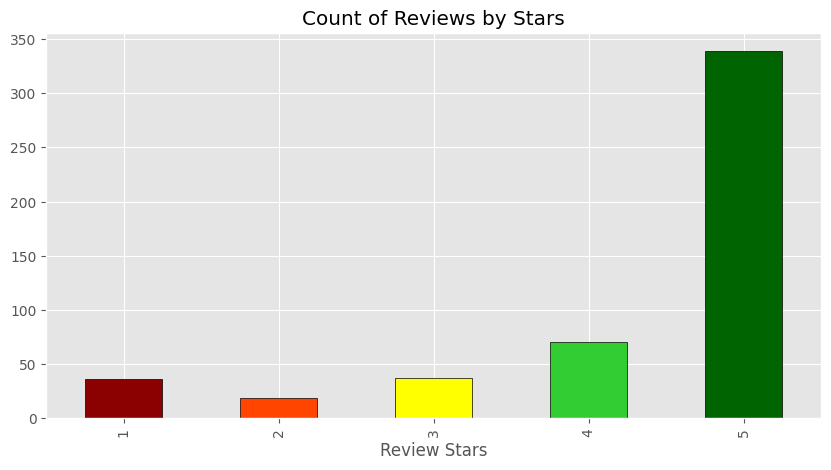

In [ ]:
colors =plt.cm.RdYlGn([0,0.25,0.5,0.75,1])
ax = df['Score'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5),
# color = colors

color=['darkred', 'orangered', 'yellow', 'limegreen', 'darkgreen'],
edgecolor='black'
)
ax.set_xlabel('Review Stars')
plt.show()

In [11]:
example = df['Text'][50]
print(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


## NLTK Processing

In [14]:
nltk.download('punkt_tab')
tokens=nltk.word_tokenize(example)
tokens[:10]

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['This', 'oatmeal', 'is', 'not', 'good', '.', 'Its', 'mushy', ',', 'soft']

In [12]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


True

In [15]:
tagged =nltk.pos_tag(tokens)
tagged[:10]

[('This', 'DT'),
 ('oatmeal', 'NN'),
 ('is', 'VBZ'),
 ('not', 'RB'),
 ('good', 'JJ'),
 ('.', '.'),
 ('Its', 'PRP$'),
 ('mushy', 'NN'),
 (',', ','),
 ('soft', 'JJ')]

In [16]:
nltk.download('words')
entites= nltk.chunk.ne_chunk(tagged)
entites.pprint()

[nltk_data] Downloading package words to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


(S
  This/DT
  oatmeal/NN
  is/VBZ
  not/RB
  good/JJ
  ./.
  Its/PRP$
  mushy/NN
  ,/,
  soft/JJ
  ,/,
  I/PRP
  do/VBP
  n't/RB
  like/VB
  it/PRP
  ./.
  (ORGANIZATION Quaker/NNP Oats/NNPS)
  is/VBZ
  the/DT
  way/NN
  to/TO
  go/VB
  ./.)


## VADAR Sentiment Analysis

In [17]:
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HOME\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [18]:
print(example)
sia.polarity_scores(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [19]:
#Run the polarity score on the entire dataset
from tqdm import tqdm
res ={}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row["Text"]
    myid = row["Id"]
    res[myid] = sia.polarity_scores(text)
    

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:00<00:00, 679.99it/s]


In [20]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={"index": "Id"})
vaders = vaders.merge(df, how = 'left') 


In [21]:
#now we have sentiment data and metadata
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


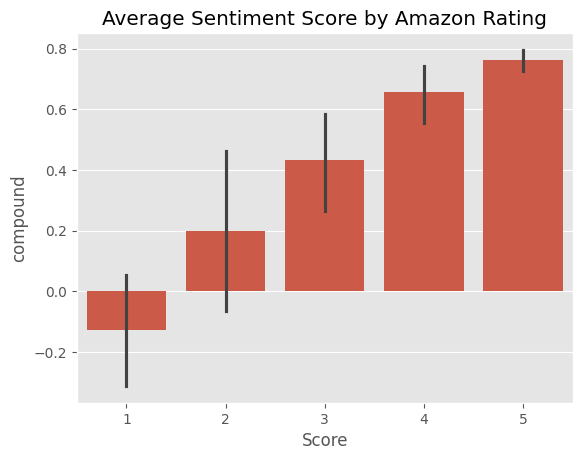

In [22]:
ax = sns.barplot(data= vaders, x="Score", y="compound")
ax.set_title("Average Sentiment Score by Amazon Rating")
plt.show()

## Sentiment Distribution Analysis

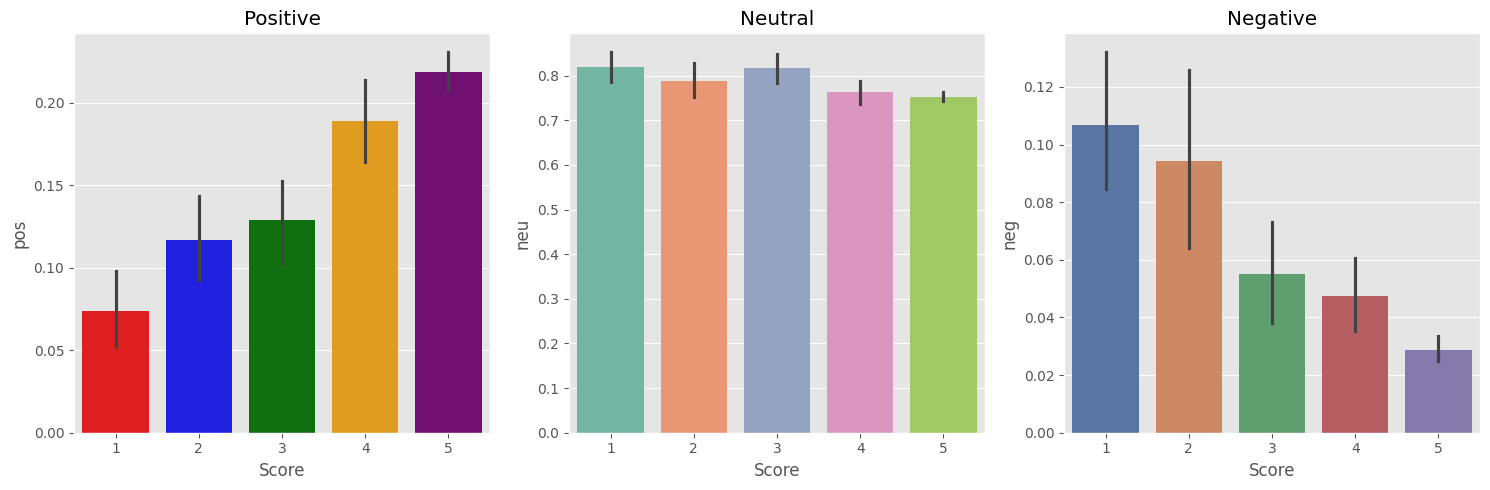

In [23]:
fig, axs = plt.subplots(1,3, figsize=(15,5))
colors=['red','blue','green','orange','purple']
sns.barplot(data=vaders, x="Score", y="pos",
            hue="Score", palette=colors,
            legend=False, ax=axs[0])

sns.barplot(data=vaders, x="Score", y="neu",
            hue="Score", palette="Set2",
            legend=False, ax=axs[1])

sns.barplot(data=vaders, x="Score", y="neg",
            hue="Score", palette="deep",
            legend=False, ax=axs[2])

axs[0].set_title("Positive")
axs[1].set_title("Neutral")
axs[2].set_title("Negative")
plt.tight_layout()
plt.show() 

In [24]:
# vader results on exapmle
print(example)
sia.polarity_scores(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [25]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax


## RoBERTa Transformer Model

In this section, we use the RoBERTa transformer model from Hugging Face for advanced sentiment analysis.

RoBERTa is a transformer-based deep learning model developed by Facebook AI and trained on large-scale text data. It provides more accurate sentiment predictions compared to traditional NLP techniques like VADER.

Model Used:
- cardiffnlp/twitter-roberta-base-sentiment

Libraries Used:
- Transformers
- PyTorch
- SciPy

In [26]:
MODEL=f"cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12562.29it/s]


In [27]:
# Run for roberta
def polarity_scores_roberta(example):   
   encoded_text = tokenizer(example, return_tensors='pt')
   output = model(**encoded_text)
   scores = output[0][0].detach().numpy()
   scores = softmax(scores)
   scores_dict = {
       'roberta_neg' : scores[0],
       'roberta_neu' : scores[1],
       'roberta_pos' : scores[2]
   }
   return scores_dict

In [28]:
from tqdm import tqdm
res ={}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
       text = row["Text"]
       myid = row["Id"]
       vadar_result = sia.polarity_scores(text)
       vadar_result_rename = {}
       for key, value in vadar_result.items():
           vadar_result_rename[f"vadar_{key}"] = value
       roberta_result = polarity_scores_roberta(text)
       both = {**vadar_result_rename,**roberta_result}
       res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')
        

 16%|█▋        | 82/500 [00:17<01:13,  5.69it/s]

Broke for id 83


 38%|███▊      | 188/500 [00:36<00:38,  8.13it/s]

Broke for id 187


100%|██████████| 500/500 [01:38<00:00,  5.10it/s]


In [29]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={"index": "Id"})
results_df = results_df.merge(df, how = 'left') 

In [30]:
results_df.head()

,Id,vadar_neg,vadar_neu,vadar_pos,vadar_compound,roberta_neg,roberta_neu,roberta_pos,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,0.009624,0.049980,0.940395,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,0.508986,0.452413,0.038600,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,0.003229,0.098067,0.898704,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,0.002295,0.090219,0.907486,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,0.001635,0.010302,0.988063,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## THE TRANSFORMERS PIPELINE

In [37]:
from transformers import pipeline
sent_pipeline = pipeline('sentiment-analysis')


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2207.32it/s]


In [38]:
sent_pipeline('i love sentiment analysis!')


[{'label': 'POSITIVE', 'score': 0.9997853636741638}]

## Comparison Between Sentiment Models

In this section, sentiment scores generated by VADER and RoBERTa models are compared using pairplot visualization.

The pairplot helps analyze:
- Relationships between sentiment features
- Distribution of sentiment scores
- Differences between traditional NLP and transformer-based sentiment analysis

Different review scores are represented using different colors.

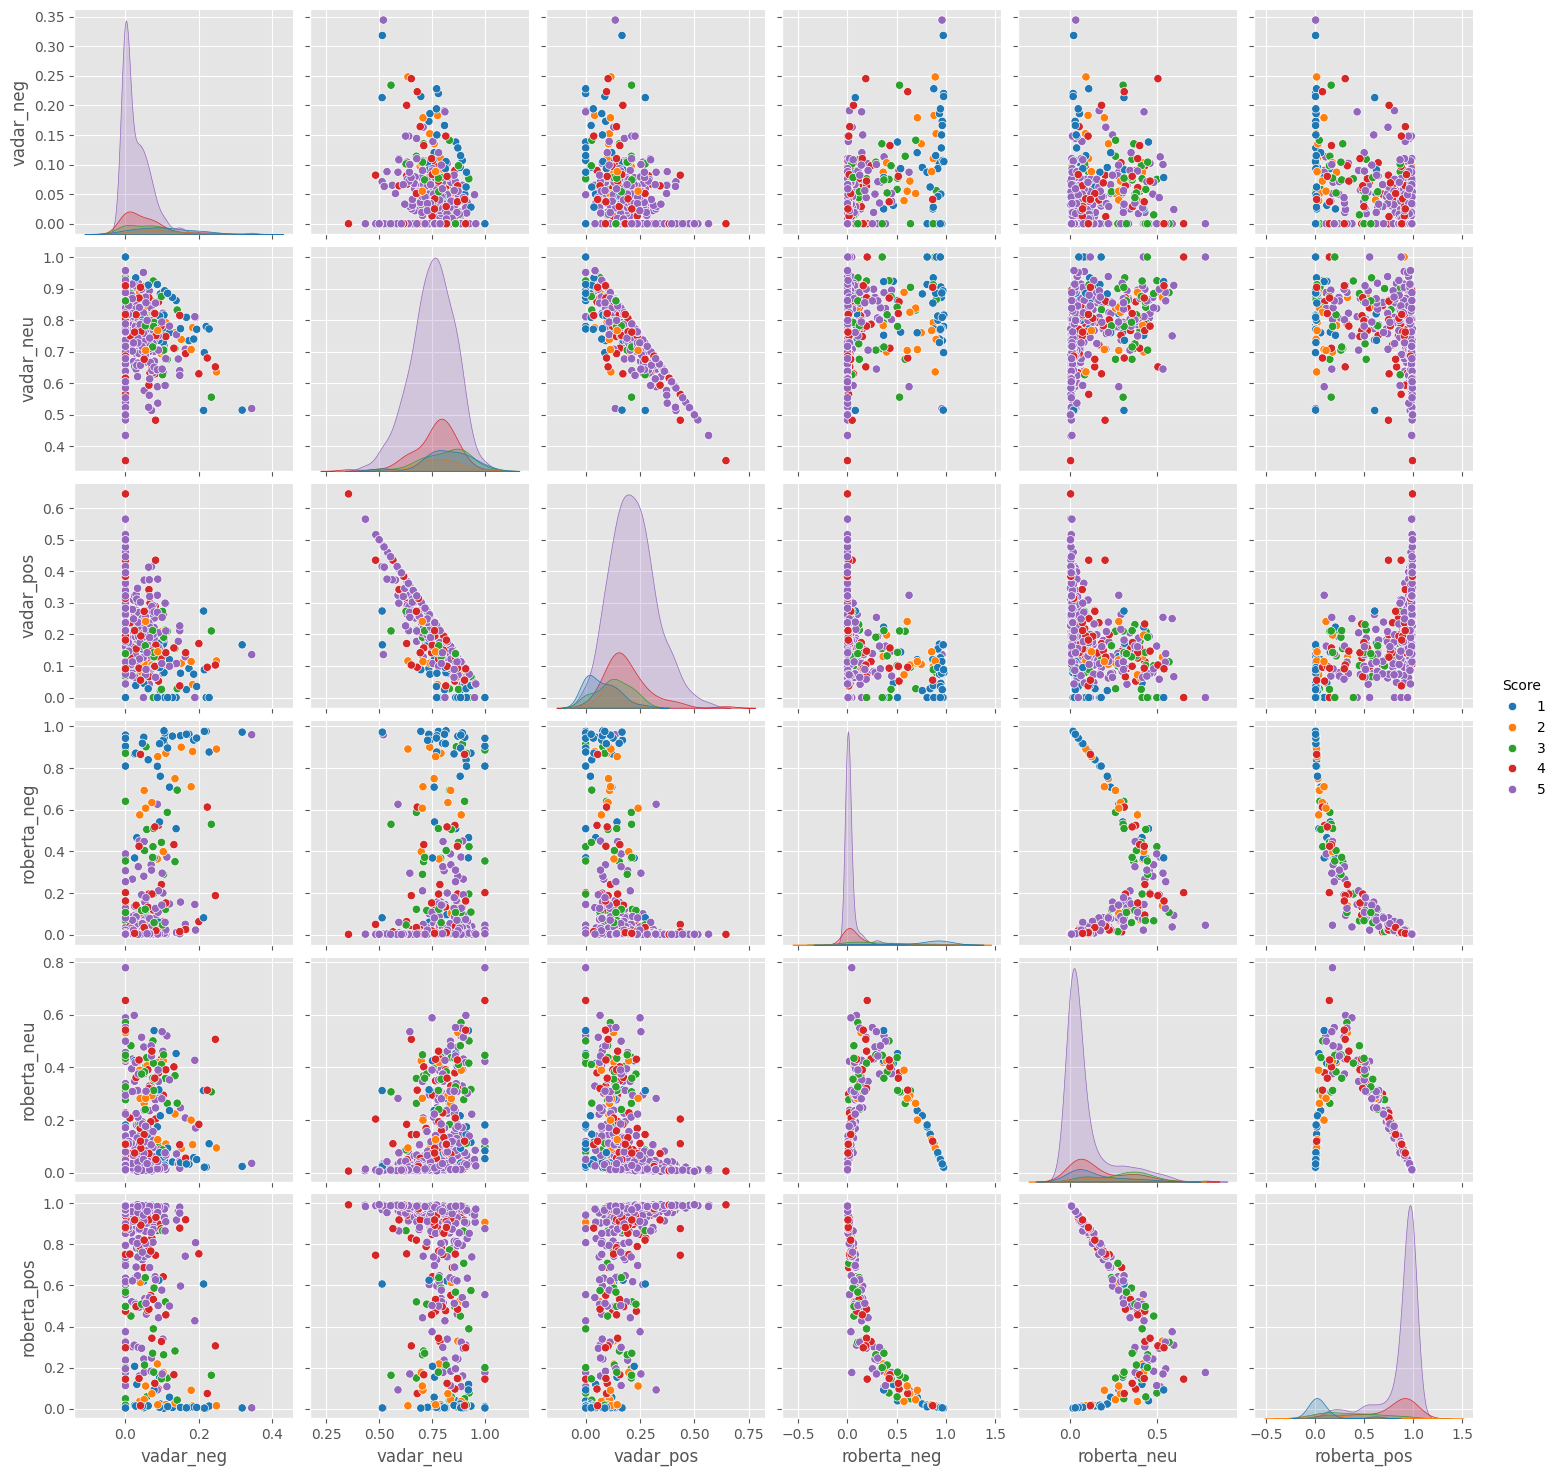

In [40]:
#compare scores between models
sns.pairplot(data=results_df, 
       vars=['vadar_neg', 'vadar_neu', 'vadar_pos',
       'roberta_neg', 'roberta_neu', 'roberta_pos'],
        hue= "Score",
        palette= 'tab10')
        # corner=True)
plt.show()



### Review Some Examples

In [32]:
#review some examples

results_df.query('Score == 1') \
.sort_values('roberta_pos', ascending = False)['Text'].values[0]

'I felt energized within five minutes, but it lasted for about 45 minutes. I paid $3.99 for this drink. I could have just drunk a cup of coffee and saved my money.'

In [33]:
results_df.query('Score == 1') \
.sort_values('vadar_pos', ascending = False)['Text'].values[0]

'So we cancelled the order.  It was cancelled without any problem.  That is a positive note...'

In [34]:
# negative sentiment 5 star view
results_df.query("Score==5") \
     .sort_values("roberta_neg", ascending = False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

In [35]:
results_df.query("Score==5") \
     .sort_values("vadar_neg", ascending = False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

# Conclusion

In this project, sentiment analysis was performed on Amazon food reviews using multiple NLP techniques.

The project started with traditional NLP approaches using NLTK and VADER sentiment analysis. Later, a transformer-based deep learning model (RoBERTa) from Hugging Face was used for advanced sentiment prediction.

Key observations:
- Positive reviews generally showed higher positive sentiment scores.
- Negative reviews showed higher negative sentiment scores.
- RoBERTa provided more context-aware and accurate sentiment predictions compared to traditional methods.

Technologies Used:
- Python
- Pandas
- NLTK
- VADER
- Hugging Face Transformers
- RoBERTa
- Matplotlib
- Seaborn

This project demonstrates the application of NLP and transformer models for real-world sentiment analysis tasks.